In [28]:
from src.api.option_fetcher import OptionFetcher
from src.analysis.volatility_smile import VolatilitySmileAnalyzer
from dotenv import load_dotenv
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
import importlib
import src.api.option_fetcher as option_fetcher
import src.analysis.volatility_smile as volatility_smile

importlib.reload(option_fetcher)
OptionFetcher = option_fetcher.OptionFetcher

importlib.reload(volatility_smile)
VolatilitySmileAnalyzer = volatility_smile.VolatilitySmileAnalyzer

In [30]:
load_dotenv()
api_key = os.getenv("API_KEY")
secret_key = os.getenv("SECRET_KEY")

In [31]:
ticker = "SPY"
expiration_date = "2026-05-15"
spot_delta = 20

In [32]:
fetcher = OptionFetcher(api_key, secret_key)
spot_price = fetcher.get_spot_price(ticker)
df = fetcher.build_options_df(ticker,expiration_date,spot_delta,100)
df

,symbol,strike,expiry,type,bid,ask,mid,spread,timestamp
0,SPY260515C00729000,729.0,2026-05-15,call,19.40,19.80,19.600,0.40,2026-05-14 19:59:59.522711+00:00
1,SPY260515C00730000,730.0,2026-05-15,call,17.99,18.18,18.085,0.19,2026-05-14 19:59:59.965477+00:00
2,SPY260515C00731000,731.0,2026-05-15,call,17.02,17.82,17.420,0.80,2026-05-14 19:59:59.477566+00:00
3,SPY260515C00732000,732.0,2026-05-15,call,16.60,16.81,16.705,0.21,2026-05-14 19:59:59.839858+00:00
4,SPY260515C00733000,733.0,2026-05-15,call,15.41,15.72,15.565,0.31,2026-05-14 19:59:59.489342+00:00
...,...,...,...,...,...,...,...,...,...
75,SPY260515P00764000,764.0,2026-05-15,put,14.58,15.82,15.200,1.24,2026-05-14 19:59:59.415189+00:00
76,SPY260515P00765000,765.0,2026-05-15,put,15.67,17.25,16.460,1.58,2026-05-14 19:59:59.492932+00:00
77,SPY260515P00766000,766.0,2026-05-15,put,16.73,17.77,17.250,1.04,2026-05-14 19:59:59.461403+00:00
78,SPY260515P00767000,767.0,2026-05-15,put,17.52,18.71,18.115,1.19,2026-05-14 19:59:59.475902+00:00


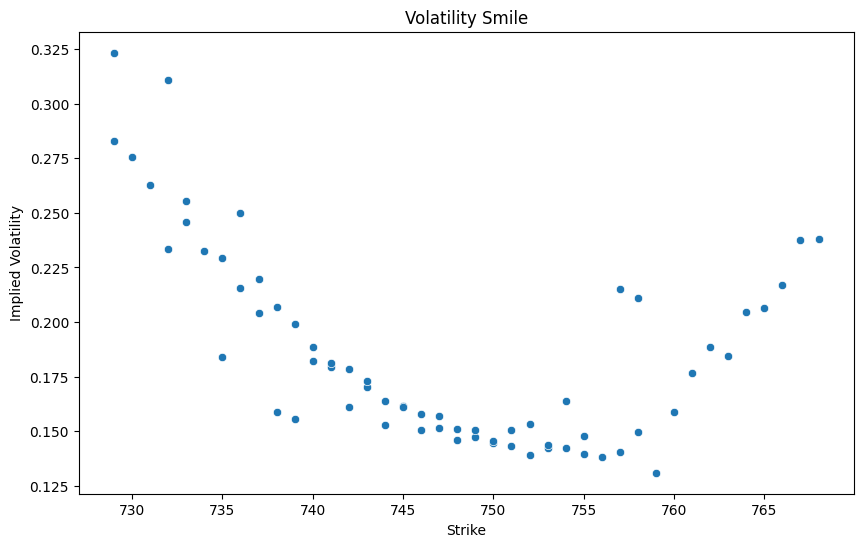

In [33]:
smile = VolatilitySmileAnalyzer(df, spot_price, 0.045)
implied_vols, strikes = smile.build_2d_smile_data()
plt.figure(figsize=(10, 6))
sns.scatterplot(x=strikes, y=implied_vols)
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title("Volatility Smile")
plt.show()